In [29]:
%pip install tensorflow

## Mount google drive

### Subtask:
Mount Google Drive to access the image data.


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load and prepare data

### Subtask:
Load the images from the specified folders, preprocess them, and create datasets for training, validation, and testing.


**Reasoning**:
Define the paths for the datasets and load and preprocess the images using `image_dataset_from_directory` to create TensorFlow datasets for training, validation, and testing.



In [31]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import preprocess_input
base_dir = '/content/drive/MyDrive/Record học/'

# Define paths for training, validation, and test sets
train_dir = base_dir + 'training_set/training_set_augmented'
validation_dir = base_dir + 'validation_set/validation_augmented'
test_dir = base_dir + 'test_set/test_set_augmented'

# Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load and preprocess training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load and preprocess validation data
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load and preprocess test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Function to scale pixel values to [0, 1]
def preprocess(image, label):
  image = tf.cast(image, tf.float32)
  # nếu ảnh đang ở [0,1] thì nhân lên 255; nếu đã ở [0,255] thì giữ nguyên
  image = tf.cond(tf.reduce_max(image) <= 1.0,
                    lambda: image * 255.0,
                    lambda: image)
  image = preprocess_input(image)   # MobileNet expects 0-255 -> returns ~[-1,1]
  return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets created successfully:")
print(f"Training dataset: {train_ds}")
print(f"Validation dataset: {validation_ds}")
print(f"Test dataset: {test_ds}")

Found 420 files belonging to 2 classes.
Found 120 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Datasets created successfully:
Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


Check data

In [32]:
# Tạo lại dataset (không map preprocess) chỉ để kiểm tra class_names/hiển thị
raw_train = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    interpolation='bilinear'
)

print("Class names (label index order):", raw_train.class_names)
# Với folder names ['hemmorhage_data','non_hemmorhage_data'],
# label 0 -> 'hemmorhage_data', label 1 -> 'non_hemmorhage_data' (alphabetical order)


Found 420 files belonging to 2 classes.
Class names (label index order): ['hemmorhage_data', 'non_hemmorhage_data']


/tmp/ipython-input-3255402407.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(raw_train.class_names[int(labels[i])])


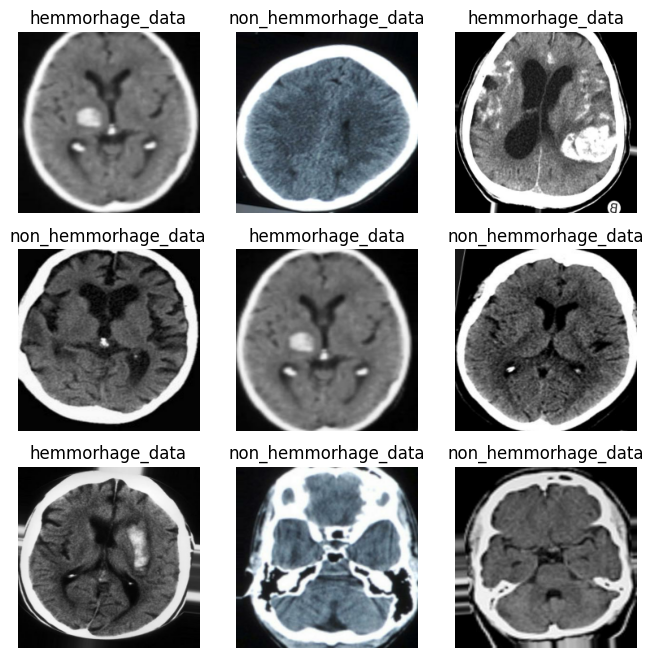

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for images, labels in raw_train.take(1):   # 1 batch
    images = images.numpy().astype("uint8")
    labels = labels.numpy()
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(raw_train.class_names[int(labels[i])])
        plt.axis('off')
plt.show()


In [34]:
import os
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes in FS (alphabetical):", classes)

for idx, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    sample_files = os.listdir(folder)[:5]
    print(f"Label {idx} -> {cls}, sample files: {sample_files}")


Classes in FS (alphabetical): ['hemmorhage_data', 'non_hemmorhage_data']
Label 0 -> hemmorhage_data, sample files: ['051_0_5759.jpg', '080_0_1020.jpg', '066_0_3197.jpg', '050_0_6699.jpg', '070_0_1485.jpg']
Label 1 -> non_hemmorhage_data, sample files: ['196_0_9261.jpg', '187_0_5104.jpg', '189_0_1769.jpg', '189_0_8301.jpg', '197_0_756.jpg']


In [35]:
import numpy as np

def count_labels(ds):
    counts = np.zeros(2, dtype=int)
    for images, labels in ds.unbatch():
        counts[int(labels.numpy())] += 1
    return counts

# dùng raw_train hoặc recreate dataset với batch_size lớn để count nhanh:
big = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(IMG_HEIGHT,IMG_WIDTH), batch_size=1024, shuffle=False)
print("Train label counts:", count_labels(big))


Found 420 files belonging to 2 classes.
Train label counts: [210 210]


## Build and compile the model

### Subtask:
Build a MobileNetV1 model for binary classification and compile it with an appropriate optimizer, loss function, and metrics.

**Reasoning**:
Define and compile the MobileNetV1 model using `MobileNetV1` from `tensorflow.keras.applications` with pre-trained weights from ImageNet, and add a dense layer for binary classification. Use Adam optimizer, Binary Crossentropy loss, and Accuracy metric.

In [36]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


IMG_HEIGHT, IMG_WIDTH = 224, 224

# Load MobileNetV1 (chính là MobileNet) pretrained trên ImageNet
base_model = MobileNet(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Add a global average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add a dropout layer
x = Dropout(0.5)(x) # You can adjust the dropout rate

# Add a dense layer for binary classification
predictions = Dense(1, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,229,889 (12.32 MB)

 Trainable params: 3,208,001 (12.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

## Train the model

### Subtask:
Train the compiled model using the training and validation datasets.

**Reasoning**:
Train the model using the `fit` method with the training and validation datasets. Specify the number of epochs.

In [37]:
EPOCHS = 60  # You can adjust the number of epochs
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7780 - loss: 0.5485 - val_accuracy: 0.8667 - val_loss: 0.3779
Epoch 2/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.9829 - loss: 0.0371 - val_accuracy: 0.6833 - val_loss: 0.8401
Epoch 3/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9846 - loss: 0.0482 - val_accuracy: 0.8833 - val_loss: 0.2255
Epoch 4/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9882 - loss: 0.0273 - val_accuracy: 0.9250 - val_loss: 0.2245
Epoch 5/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9931 - loss: 0.0295 - val_accuracy: 0.8833 - val_loss: 0.5829
Epoch 6/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8833 - val_loss: 0.5360
Epoch 7/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 1.0000 - loss: 2.7278e-04 - val_accuracy: 0.9000 - val_loss: 0.4604
Epoch 8/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 1.0000 - loss: 2.8011e-04 - val_accuracy: 0.

## Evaluate the model

### Subtask:
Evaluate the trained model using the test dataset to assess its performance on unseen data.

**Reasoning**:
Evaluate the trained model on the test dataset using the `evaluate` method to determine its loss and accuracy on unseen data.

In [38]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.9624 - loss: 0.1475
Test Loss: 0.30722278356552124
Test Accuracy: 0.9222221970558167


## Make predictions

### Subtask:
Make predictions on the test dataset using the trained model.

**Reasoning**:
Use the `predict` method to generate predictions for the test dataset.

In [39]:
# Make predictions on the test set
predictions = model.predict(test_ds)
loss, accuracy = model.evaluate(test_ds)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9624 - loss: 0.1475
Test loss: 0.3072
Test accuracy: 0.9222


## Display predictions

### Subtask:
Display the predictions made by the model.

**Reasoning**:
Display the predictions. Since this is a binary classification problem with a sigmoid activation in the output layer, the predictions will be probabilities between 0 and 1.

In [40]:
import numpy as np

# Display the first few predictions
print("Sample predictions:")
for i in range(min(10, len(predictions))):
    print(f"Prediction {i+1}: {predictions[i][0]:.4f}")

# You can also convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(np.int32)
print("\nSample predicted classes:")
for i in range(min(10, len(predicted_classes))):
    print(f"Predicted class {i+1}: {predicted_classes[i][0]}")

Sample predictions:
Prediction 1: 0.0000
Prediction 2: 0.0000
Prediction 3: 0.0000
Prediction 4: 0.0000
Prediction 5: 0.0000
Prediction 6: 0.0000
Prediction 7: 0.0031
Prediction 8: 0.0016
Prediction 9: 0.0005
Prediction 10: 0.0000

Sample predicted classes:
Predicted class 1: 0
Predicted class 2: 0
Predicted class 3: 0
Predicted class 4: 0
Predicted class 5: 0
Predicted class 6: 0
Predicted class 7: 0
Predicted class 8: 0
Predicted class 9: 0
Predicted class 10: 0


## Visualize training results

### Subtask:
Visualize the training and validation accuracy and loss over epochs.

**Reasoning**:
Plot the accuracy and loss for both the training and validation datasets across the epochs to visualize the model's learning progress and identify potential overfitting.

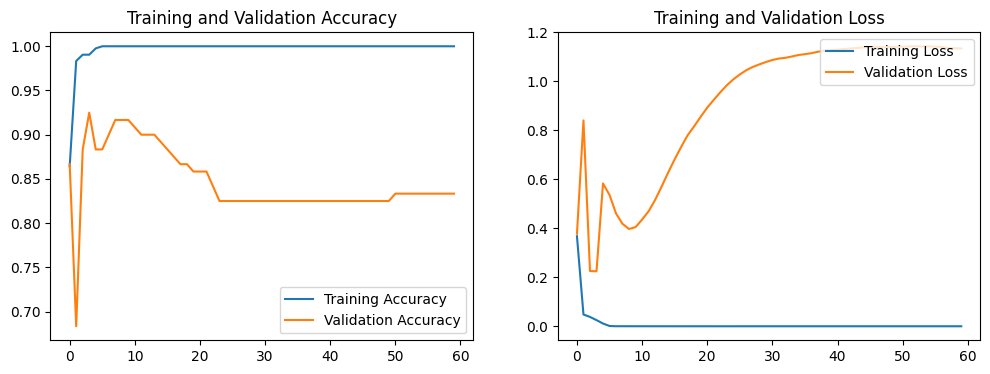

In [41]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()